# ===============================================================
# CS4237: DATA MINING & WAREHOUSING
# PROJECT - UCI Online Retail II Analysis
# AUTHOR: AMA BADUWA BAIDOO
# ROLL NUMBER: 10012200033
# ===============================================================



# TASK 2: DATA ENGINEERING & ETL IMPLEMENTATION
# ===============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=" * 60)
print("ETL PIPELINE INITIALIZED")
print("=" * 60)
print(f"Session started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Pandas version: {pd.__version__}")

ETL PIPELINE INITIALIZED
Session started at: 2026-04-14 20:23:11
Pandas version: 2.2.2


In [2]:
# ============================================
# LOAD DATASET DIRECTLY FROM UCI (NO UPLOAD NEEDED)
# ============================================

print("\n📥 Loading dataset directly from UCI Repository...")

# UCI Online Retail II dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx"

# Load the dataset directly
df_raw = pd.read_excel(url)

# Rename 'Customer ID' to 'CustomerID' for consistency
if 'Customer ID' in df_raw.columns:
    df_raw.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

print(f"\n✅ Dataset loaded successfully!")
print(f"   - Total rows: {df_raw.shape[0]:,}")
print(f"   - Total columns: {df_raw.shape[1]}")
print(f"   - Data size: ~{df_raw.memory_usage(deep=True).sum() / (1024*1024):.2f} MB")
print(f"\n📋 Column names:")
print(df_raw.columns.tolist())


📥 Loading dataset directly from UCI Repository...

✅ Dataset loaded successfully!
   - Total rows: 525,461
   - Total columns: 8
   - Data size: ~122.87 MB

📋 Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


In [3]:
# ============================================
# DATA PROFILING - Understand before cleaning
# ============================================

print("\n" + "=" * 60)
print("DATA PROFILING")
print("=" * 60)

print("\n📋 First 5 rows of raw data:")
display(df_raw.head())

print("\n📊 Data Types & Missing Values Summary:")
data_info = pd.DataFrame({
    'Data_Type': df_raw.dtypes,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Percentage': (df_raw.isnull().sum() / len(df_raw)) * 100,
    'Unique_Values': df_raw.nunique()
})
print(data_info)

print("\n📈 Statistical Summary (Numeric Columns):")
display(df_raw.describe())

print("\n⚠️ Data Quality Checks:")
print(f"   - Negative Quantity rows: {(df_raw['Quantity'] < 0).sum():,}")
print(f"   - Negative Price rows: {(df_raw['Price'] < 0).sum():,}")
print(f"   - Zero Price rows: {(df_raw['Price'] == 0).sum():,}")
print(f"   - Missing CustomerID: {df_raw['CustomerID'].isnull().sum():,}")


DATA PROFILING

📋 First 5 rows of raw data:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



📊 Data Types & Missing Values Summary:
                  Data_Type  Missing_Count  Missing_Percentage  Unique_Values
Invoice              object              0            0.000000          28816
StockCode            object              0            0.000000           4632
Description          object           2928            0.557225           4681
Quantity              int64              0            0.000000            825
InvoiceDate  datetime64[ns]              0            0.000000          25296
Price               float64              0            0.000000           1606
CustomerID          float64         107927           20.539488           4383
Country              object              0            0.000000             40

📈 Statistical Summary (Numeric Columns):


,Quantity,InvoiceDate,Price,CustomerID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316



⚠️ Data Quality Checks:
   - Negative Quantity rows: 12,326
   - Negative Price rows: 3
   - Zero Price rows: 3,687
   - Missing CustomerID: 107,927


In [4]:
# ============================================
# 2a: EXTRACTION STRATEGY - FULL EXTRACTION
# ============================================

print("\n" + "=" * 60)
print("2a: EXTRACTION STRATEGY")
print("=" * 60)

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                    EXTRACTION STRATEGY: FULL EXTRACTION                        ║
╚═══════════════════════════════════════════════════════════════════════════════╝

RATIONALE FOR CHOOSING FULL EXTRACTION FOR DAILY UPDATES

COMPARISON: FULL vs INCREMENTAL

   ┌────────────────────┬──────────────────────┬──────────────────────┐
   │ Factor             │ Full Extraction      │ Incremental          │
   ├────────────────────┼──────────────────────┼──────────────────────┤
   │ Complexity         │ Low                  │ High                 │
   │ Data Consistency   │ 100% accurate        │ Risk of drift        │
   │ Error Recovery     │ Simple (re-run)      │ Complex              │
   │ Processing Time    │ Moderate (minutes)   │ Fast (seconds)       │
   │ Capture Corrections│ Yes                  │ No (unless tracked)  │
   │ Maintenance Cost   │ Low                  │ High                 │
   └────────────────────┴──────────────────────┴──────────────────────┘
""")

# Calculate daily volume
df_raw['Date_Temp'] = pd.to_datetime(df_raw['InvoiceDate']).dt.date
daily_volume = df_raw.groupby('Date_Temp').size()
avg_daily = daily_volume.mean()
max_daily = daily_volume.max()

print("\n📊 FEASIBILITY ANALYSIS:")
print(f"   - Total rows: {len(df_raw):,}")
print(f"   - Average daily rows: {avg_daily:,.0f}")
print(f"   - Maximum daily rows: {max_daily:,}")
print(f"   - Estimated extraction time: ~{max(1, int(len(df_raw)/100000))} minutes")
print(f"\n   ✅ CONCLUSION: Full extraction is feasible and RECOMMENDED for daily updates.")

# Remove temporary column
df_raw.drop(columns=['Date_Temp'], inplace=True)


2a: EXTRACTION STRATEGY

╔═══════════════════════════════════════════════════════════════════════════════╗
║                    EXTRACTION STRATEGY: FULL EXTRACTION                        ║
╚═══════════════════════════════════════════════════════════════════════════════╝

RATIONALE FOR CHOOSING FULL EXTRACTION FOR DAILY UPDATES

COMPARISON: FULL vs INCREMENTAL

   ┌────────────────────┬──────────────────────┬──────────────────────┐
   │ Factor             │ Full Extraction      │ Incremental          │
   ├────────────────────┼──────────────────────┼──────────────────────┤
   │ Complexity         │ Low                  │ High                 │
   │ Data Consistency   │ 100% accurate        │ Risk of drift        │
   │ Error Recovery     │ Simple (re-run)      │ Complex              │
   │ Processing Time    │ Moderate (minutes)   │ Fast (seconds)       │
   │ Capture Corrections│ Yes                  │ No (unless tracked)  │
   │ Maintenance Cost   │ Low                  │ High      

In [5]:
# ============================================
# 2b: TRANSFORMATION - STEP 1: HANDLING NULLS (5% THRESHOLD APPROACH)
# ============================================

print("\n" + "=" * 60)
print("2b: TRANSFORMATION - STEP 1: HANDLING NULL VALUES")
print("=" * 60)

# Create a copy for transformation
df_clean = df_raw.copy()

print("\n🔍 Missing Values Analysis:")
missing_analysis = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Pct': (df_clean.isnull().sum() / len(df_clean)) * 100
}).sort_values('Missing_Count', ascending=False)
print(missing_analysis)

# ============================================
# DATA QUALITY DECISION: CustomerID Nulls
# ============================================

print("\n" + "=" * 60)
print("DATA QUALITY DECISION: CustomerID Missing Values")
print("=" * 60)

missing_customer_pct = (df_clean['CustomerID'].isnull().sum() / len(df_clean)) * 100
print(f"\n📊 Missing CustomerID: {missing_customer_pct:.2f}%")

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                    DATA QUALITY THRESHOLD ANALYSIS                            ║
╚═══════════════════════════════════════════════════════════════════════════════╝

Industry Standard Thresholds for Missing Data:
   • < 5%: Drop rows (acceptable loss)
   • 5-15%: Investigate and consider imputation
   • > 15%: PRESERVE data, handle strategically

YOUR CASE: 20.54% missing CustomerID → EXCEEDS 5% THRESHOLD

RECOMMENDED STRATEGY: PRESERVE ALL DATA WITH FLAGGING
   • Keep all 525,461 transactions
   • Flag missing CustomerIDs with placeholder (-1)
   • Document limitation for customer-specific analyses
   • Use complete cases only for clustering

RATIONALE:
   • Dropping 20% of transactions would introduce significant bias
   • Sales trends and product associations are unaffected by CustomerID
   • Market Basket Analysis benefits from ALL transactions
   • Customer clustering will filter to verified customers only
""")

# Preserve all data - fill missing CustomerID with placeholder
missing_count = df_clean['CustomerID'].isnull().sum()
df_clean['CustomerID_Missing'] = df_clean['CustomerID'].isnull()
df_clean['CustomerID'] = df_clean['CustomerID'].fillna(-1)

print(f"\n✅ REVISED APPROACH (Preserve Data):")
print(f"   • Original rows: {len(df_raw):,}")
print(f"   • Missing CustomerID: {missing_count:,} ({missing_customer_pct:.2f}%)")
print(f"   • Action: Filled with placeholder (-1) and flagged")
print(f"   • Rows preserved: {len(df_clean):,} (100% preserved)")

# Handle Description nulls (minor - <1%)
print("\n🎯 STRATEGY 2: Handling Description Nulls")
desc_null = df_clean['Description'].isnull().sum()
desc_null_pct = (desc_null / len(df_clean)) * 100
print(f"   • Missing descriptions: {desc_null:,} ({desc_null_pct:.2f}%)")
print(f"   • Threshold: <5% → Filling with 'Unknown_Product' is acceptable")

df_clean['Description'] = df_clean['Description'].fillna('Unknown_Product')
print(f"   ✓ Filled {desc_null:,} missing descriptions")

# Validation
print("\n✅ NULL HANDLING VALIDATION:")
remaining_nulls = df_clean.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls) == 0:
    print("   ✓ NO remaining null values in dataset!")
    print(f"   ✓ All {len(df_clean):,} rows preserved!")
else:
    print(remaining_nulls)

# Impact analysis
print("\n📊 IMPACT ANALYSIS:")
total_rows = len(df_clean)
complete_customers = df_clean[df_clean['CustomerID'] != -1].shape[0]
unknown_customers = df_clean[df_clean['CustomerID'] == -1].shape[0]
print(f"   • Total rows for Market Basket Analysis: {total_rows:,} (100%)")
print(f"   • Complete customer records: {complete_customers:,} ({complete_customers/total_rows*100:.1f}%)")
print(f"   • Unknown customer transactions (flagged): {unknown_customers:,} ({unknown_customers/total_rows*100:.1f}%)")


2b: TRANSFORMATION - STEP 1: HANDLING NULL VALUES

🔍 Missing Values Analysis:
                  Column  Missing_Count  Missing_Pct
CustomerID    CustomerID         107927    20.539488
Description  Description           2928     0.557225
StockCode      StockCode              0     0.000000
Invoice          Invoice              0     0.000000
Quantity        Quantity              0     0.000000
InvoiceDate  InvoiceDate              0     0.000000
Price              Price              0     0.000000
Country          Country              0     0.000000

DATA QUALITY DECISION: CustomerID Missing Values

📊 Missing CustomerID: 20.54%

╔═══════════════════════════════════════════════════════════════════════════════╗
║                    DATA QUALITY THRESHOLD ANALYSIS                            ║
╚═══════════════════════════════════════════════════════════════════════════════╝

Industry Standard Thresholds for Missing Data:
   • < 5%: Drop rows (acceptable loss)
   • 5-15%: Investigate and co

In [6]:
# ============================================
# 2b: TRANSFORMATION - STEP 3: DE-DUPLICATION (CORRECTED)
# ============================================

print("\n" + "=" * 60)
print("2b: TRANSFORMATION - STEP 3: DE-DUPLICATION")
print("=" * 60)

print("\n🔍 Duplicate Analysis:")

# Exact duplicates
exact_dupes = df_clean.duplicated()
exact_dupe_count = exact_dupes.sum()
print(f"   • Exact duplicate rows: {exact_dupe_count:,}")

# Transaction-level duplicates
trans_dupes = df_clean.duplicated(subset=['Invoice', 'StockCode', 'CustomerID', 'InvoiceDate'], keep=False)
trans_dupe_groups = df_clean[trans_dupes].groupby(['Invoice', 'StockCode', 'CustomerID', 'InvoiceDate']).size()
duplicate_groups = len(trans_dupe_groups[trans_dupe_groups > 1])
print(f"   • Transaction-level duplicate groups: {duplicate_groups}")

print("\n🎯 DE-DUPLICATION STRATEGY:")
print("   • Step 1: Remove exact duplicate rows (data entry errors)")
print("   • Step 2: For logical duplicates, sum quantities and keep ONE record")

# Step 1: Remove exact duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
removed_exact = before - after
print(f"\n   Step 1 Complete:")
print(f"      - Removed exact duplicates: {removed_exact:,} rows")
print(f"      - Remaining: {after:,} rows")

# Step 2: Handle logical duplicates (CORRECTED - no explosion)
print(f"\n   Step 2: Aggregating logical duplicates...")

# Identify rows that are part of duplicate groups
dupe_mask = df_clean.duplicated(subset=['Invoice', 'StockCode', 'CustomerID', 'InvoiceDate'], keep=False)

if dupe_mask.any():
    # Separate duplicates and non-duplicates
    df_dupes = df_clean[dupe_mask].copy()
    df_unique = df_clean[~dupe_mask].copy()

    print(f"      - Rows in duplicate groups: {len(df_dupes):,}")
    print(f"      - Unique rows: {len(df_unique):,}")

    # Aggregate duplicates by summing quantities
    agg_columns = ['Invoice', 'StockCode', 'CustomerID', 'InvoiceDate', 'Description', 'Country', 'CustomerID_Missing']
    df_aggregated = df_dupes.groupby(agg_columns).agg({
        'Quantity': 'sum',
        'Price': 'first'
    }).reset_index()

    print(f"      - After aggregation: {len(df_aggregated):,} rows")

    # Combine unique rows with aggregated duplicates
    df_clean = pd.concat([df_unique, df_aggregated], ignore_index=True)
    print(f"      - Final rows: {len(df_clean):,}")
else:
    print(f"      - No logical duplicates found")

print("\n✅ DE-DUPLICATION VALIDATION:")
print(f"   • Unique invoices: {df_clean['Invoice'].nunique():,}")
print(f"   • Unique customers (verified): {df_clean[df_clean['CustomerID'] != -1]['CustomerID'].nunique():,}")
print(f"   • Unique products: {df_clean['StockCode'].nunique():,}")
print(f"   • Final row count: {len(df_clean):,}")


2b: TRANSFORMATION - STEP 3: DE-DUPLICATION

🔍 Duplicate Analysis:
   • Exact duplicate rows: 6,865
   • Transaction-level duplicate groups: 12061

🎯 DE-DUPLICATION STRATEGY:
   • Step 1: Remove exact duplicate rows (data entry errors)
   • Step 2: For logical duplicates, sum quantities and keep ONE record

   Step 1 Complete:
      - Removed exact duplicates: 6,865 rows
      - Remaining: 518,596 rows

   Step 2: Aggregating logical duplicates...
      - Rows in duplicate groups: 12,688
      - Unique rows: 505,908
      - After aggregation: 6,221 rows
      - Final rows: 512,129

✅ DE-DUPLICATION VALIDATION:
   • Unique invoices: 28,816
   • Unique customers (verified): 4,383
   • Unique products: 4,632
   • Final row count: 512,129


In [7]:
# ============================================
# ADDITIONAL DATA QUALITY ENHANCEMENTS
# ============================================

print("\n" + "=" * 60)
print("ADDITIONAL DATA QUALITY ENHANCEMENTS")
print("=" * 60)

# Handle negative quantities (returns)
neg_qty = (df_clean['Quantity'] < 0).sum()
print(f"\n🔄 Returns (Negative Quantities): {neg_qty:,} ({neg_qty/len(df_clean)*100:.2f}%)")
df_clean['Is_Return'] = df_clean['Quantity'] < 0
df_clean['Absolute_Quantity'] = df_clean['Quantity'].abs()

# Handle invalid prices (remove, as these are data errors)
invalid_price = (df_clean['Price'] <= 0).sum()
print(f"\n💰 Invalid Prices (<=0): {invalid_price:,}")
before_price = len(df_clean)
df_clean = df_clean[df_clean['Price'] > 0]
print(f"   • Removed: {before_price - len(df_clean):,} rows with invalid prices")

# Create calculated metric
df_clean['Total_Amount'] = df_clean['Quantity'] * df_clean['Price']
print(f"\n📊 Added: Total_Amount = Quantity × Price")

# Remove cancelled invoices (invoices starting with 'C')
cancelled = df_clean['Invoice'].astype(str).str.startswith('C').sum()
before_cancel = len(df_clean)
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f"\n🚫 Cancelled invoices removed: {cancelled:,} rows")


ADDITIONAL DATA QUALITY ENHANCEMENTS

🔄 Returns (Negative Quantities): 12,218 (2.39%)

💰 Invalid Prices (<=0): 3,672
   • Removed: 3,672 rows with invalid prices

📊 Added: Total_Amount = Quantity × Price

🚫 Cancelled invoices removed: 10,098 rows


In [8]:
# ============================================
# FINAL CLEAN DATASET SUMMARY
# ============================================

print("\n" + "=" * 60)
print("✅ FINAL CLEAN DATASET SUMMARY")
print("=" * 60)

print(f"\n📊 Statistics:")
print(f"   • Total rows: {len(df_clean):,}")
print(f"   • Total columns: {len(df_clean.columns)}")
print(f"   • Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"   • Unique customers (verified, non-placeholder): {df_clean[df_clean['CustomerID'] != -1]['CustomerID'].nunique():,}")
print(f"   • Unique products: {df_clean['StockCode'].nunique():,}")
print(f"   • Total sales value: £{df_clean['Total_Amount'].sum():,.2f}")

print(f"\n📋 Final columns ({len(df_clean.columns)} total):")
print(df_clean.columns.tolist())

print(f"\n📋 Sample of cleaned data:")
display(df_clean.head(10))

print(f"\n📊 Data Quality Summary:")
print(f"   • Original rows: 525,461")
print(f"   • Rows after cleaning: {len(df_clean):,}")
print(f"   • Rows removed: {525461 - len(df_clean):,} ({((525461 - len(df_clean))/525461)*100:.2f}%)")
print(f"   • CustomerID missing rate (preserved): 20.54% (flagged)")
print(f"   • Records with missing CustomerID preserved: {df_clean['CustomerID_Missing'].sum():,}")


✅ FINAL CLEAN DATASET SUMMARY

📊 Statistics:
   • Total rows: 498,359
   • Total columns: 12
   • Date range: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
   • Unique customers (verified, non-placeholder): 4,312
   • Unique products: 4,251
   • Total sales value: £22,084,220.58

📋 Final columns (12 total):
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'CustomerID_Missing', 'Is_Return', 'Absolute_Quantity', 'Total_Amount']

📋 Sample of cleaned data:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,CustomerID_Missing,Is_Return,Absolute_Quantity,Total_Amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,False,12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,False,48,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,False,24,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,False,False,24,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,False,24,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,False,False,10,59.5
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,False,False,12,30.6
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,False,False,12,45.0



📊 Data Quality Summary:
   • Original rows: 525,461
   • Rows after cleaning: 498,359
   • Rows removed: 27,102 (5.16%)
   • CustomerID missing rate (preserved): 20.54% (flagged)
   • Records with missing CustomerID preserved: 103,397


In [9]:
# ============================================
# 2c: LOADING STRATEGY - UPSERT METHOD
# ============================================

print("\n" + "=" * 60)
print("2c: LOADING STRATEGY - UPSERT METHOD")
print("=" * 60)

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                          UPSERT METHOD EXPLANATION                            ║
╚═══════════════════════════════════════════════════════════════════════════════╝

WHAT IS UPSERT?
   UPSERT = UPDATE + INSERT
   A database operation that inserts a new record if it doesn't exist,
   or updates an existing record if it does exist.

WHY UPSERT IS USEFUL FOR UPDATING EXISTING CUSTOMER RECORDS:

1. PRESERVES HISTORICAL CONTINUITY:
   • Customer IDs remain consistent across loads
   • Enables longitudinal analysis of customer behavior
   • Maintains referential integrity with fact tables

2. HANDLES CHANGING ATTRIBUTES:
   • Customer behavior evolves over time
   • UPSERT updates aggregated metrics (total spend, frequency)
   • New purchases are added to existing customer profiles

3. PREVENTS DUPLICATION:
   • Running the ETL multiple times doesn't create duplicates
   • Each customer appears exactly once in dimension tables

4. IDEMPOTENCY:
   • Running the same ETL pipeline multiple times yields same result
   • Allows safe reprocessing without data corruption

5. OPTIMIZES STORAGE:
   • Single source of truth for current customer state
   • No need for complex SCD Type 2 tracking unless required
""")

# DEMONSTRATION
print("\n💡 UPSERT DEMONSTRATION: Customer Dimension Update")
print("-" * 50)

# Create customer dimension (only verified customers)
verified_customers = df_clean[df_clean['CustomerID'] != -1].copy()

customer_dim = verified_customers.groupby('CustomerID').agg({
    'Country': 'first',
    'InvoiceDate': ['min', 'max'], # Changed from InvoiceDate_Datetime
    'Total_Amount': 'sum',
    'Invoice': 'count'
}).reset_index()
customer_dim.columns = ['CustomerID', 'Country', 'First_Purchase', 'Last_Purchase', 'Total_Spend', 'Transaction_Count']
customer_dim['Last_Updated'] = datetime.now()

print(f"\n📋 Current Customer Dimension (Verified Customers Only):")
print(f"   • Total customers: {len(customer_dim):,}")
print(f"   • Total spend: £{customer_dim['Total_Spend'].sum():,.2f}")
print(f"   • Avg spend per customer: £{customer_dim['Total_Spend'].mean():,.2f}")

# Simulate new daily data
today = df_clean['InvoiceDate'].max() # Changed from InvoiceDate_Datetime
new_transactions = df_clean[df_clean['InvoiceDate'] > (today - pd.Timedelta(days=7))].copy() # Changed from InvoiceDate_Datetime

print(f"\n📥 New Data to Process (Last 7 Days):")
print(f"   • New transactions: {len(new_transactions):,}")

# UPSERT simulation
incoming_customers = set(new_transactions[new_transactions['CustomerID'] != -1]['CustomerID'].unique())
existing_customers = set(customer_dim['CustomerID'].unique())
new_customers = incoming_customers - existing_customers
existing_updates = incoming_customers & existing_customers

print(f"\n🔄 UPSERT Operation Breakdown:")
print(f"   • INSERT (new customers): {len(new_customers)}")
print(f"   • UPDATE (existing customers): {len(existing_updates)}")

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    UPSERT IMPLEMENTATION PSEUDO-CODE                        │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  -- Step 1: Update existing customer records                                │
│  UPDATE customer_dimension cd                                               │
│  SET                                                                        │
│      Total_Spend = cd.Total_Spend + new_data.Total_Amount,                  │
│      Transaction_Count = cd.Transaction_Count + new_data.Transaction_Count, │
│      Last_Purchase = GREATEST(cd.Last_Purchase, new_data.Last_Purchase),    │
│      Last_Updated = CURRENT_TIMESTAMP                                       │
│  FROM staging_customer_updates new_data                                     │
│  WHERE cd.CustomerID = new_data.CustomerID;                                 │
│                                                                             │
│  -- Step 2: Insert new customers                                            │
│  INSERT INTO customer_dimension                                             │
│  SELECT                                                                     │
│      CustomerID,                                                            │
│      Country,                                                               │
│      MIN(InvoiceDate) as First_Purchase,                                    │
│      MAX(InvoiceDate) as Last_Purchase,                                     │
│      SUM(Total_Amount) as Total_Spend,                                      │
│      COUNT(DISTINCT Invoice) as Transaction_Count,                          │
│      CURRENT_TIMESTAMP as Last_Updated                                      │
│  FROM staging_new_customers                                                 │
│  GROUP BY CustomerID, Country;                                              │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")


2c: LOADING STRATEGY - UPSERT METHOD

╔═══════════════════════════════════════════════════════════════════════════════╗
║                          UPSERT METHOD EXPLANATION                            ║
╚═══════════════════════════════════════════════════════════════════════════════╝

WHAT IS UPSERT?
   UPSERT = UPDATE + INSERT
   A database operation that inserts a new record if it doesn't exist,
   or updates an existing record if it does exist.

WHY UPSERT IS USEFUL FOR UPDATING EXISTING CUSTOMER RECORDS:

1. PRESERVES HISTORICAL CONTINUITY:
   • Customer IDs remain consistent across loads
   • Enables longitudinal analysis of customer behavior
   • Maintains referential integrity with fact tables

2. HANDLES CHANGING ATTRIBUTES:
   • Customer behavior evolves over time
   • UPSERT updates aggregated metrics (total spend, frequency)
   • New purchases are added to existing customer profiles

3. PREVENTS DUPLICATION:
   • Running the ETL multiple times doesn't create duplicates
   • 

In [10]:
# ============================================
# SAVE DATA FOR TASK 3 ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("SAVING DATA FOR TASK 3 ANALYSIS")
print("=" * 60)

# Save transaction-level data for Market Basket Analysis
df_clean.to_csv('cleaned_online_retail.csv', index=False)
print("✅ Saved: cleaned_online_retail.csv (Transaction-level data for Market Basket Analysis)")

# Create customer summary for clustering (only verified customers)
customer_summary = df_clean[df_clean['CustomerID'] != -1].groupby('CustomerID').agg({
    'Total_Amount': 'sum',
    'Invoice': 'nunique',
    'Quantity': 'sum',
    'StockCode': 'nunique'
}).reset_index()

customer_summary.columns = ['CustomerID', 'TotalSpend', 'TransactionFrequency', 'TotalItems', 'ProductVariety']
customer_summary.to_csv('customer_summary_for_clustering.csv', index=False)
print("✅ Saved: customer_summary_for_clustering.csv (Customer-level data for K-Means Clustering)")

print("\n" + "=" * 60)
print("🎉 TASK 2: ETL IMPLEMENTATION COMPLETE!")
print("=" * 60)

print("\n📁 Files Ready for Task 3:")
print("   • cleaned_online_retail.csv → Market Basket Analysis (Option B)")
print("   • customer_summary_for_clustering.csv → K-Means Clustering (Option A)")

print("\n📊 Final Data Quality Summary:")
print(f"   • Original rows: 525,461")
print(f"   • Final rows: {len(df_clean):,}")
print(f"   • Preserved: {len(df_clean)/525461*100:.1f}% of original data")
print(f"   • Verified customers for clustering: {len(customer_summary):,}")
print(f"   • Total sales value: £{df_clean['Total_Amount'].sum():,.2f}")


SAVING DATA FOR TASK 3 ANALYSIS
✅ Saved: cleaned_online_retail.csv (Transaction-level data for Market Basket Analysis)
✅ Saved: customer_summary_for_clustering.csv (Customer-level data for K-Means Clustering)

🎉 TASK 2: ETL IMPLEMENTATION COMPLETE!

📁 Files Ready for Task 3:
   • cleaned_online_retail.csv → Market Basket Analysis (Option B)
   • customer_summary_for_clustering.csv → K-Means Clustering (Option A)

📊 Final Data Quality Summary:
   • Original rows: 525,461
   • Final rows: 498,359
   • Preserved: 94.8% of original data
   • Verified customers for clustering: 4,312
   • Total sales value: £22,084,220.58


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# TASK 3: KNOWLEDGE DISCOVERY & DATA MINING
# ===============================================================

## OPTION A: K-MEANS CLUSTERING
## Customer Segmentation Analysis
## ============================================


In [12]:
print("=" * 60)
print("TASK 3A: K-MEANS CLUSTERING - CUSTOMER SEGMENTATION")
print("=" * 60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

TASK 3A: K-MEANS CLUSTERING - CUSTOMER SEGMENTATION


In [13]:
# ============================================
# STEP 1: LOAD CUSTOMER DATA
# ============================================

print("\n📥 Step 1: Loading customer summary data...")

customer_df = pd.read_csv('customer_summary_for_clustering.csv')
print(f"✅ Loaded {len(customer_df)} verified customers")
print(f"   Columns: {customer_df.columns.tolist()}")

print("\n📊 Customer Summary Statistics:")
display(customer_df.describe())


📥 Step 1: Loading customer summary data...
✅ Loaded 4312 verified customers
   Columns: ['CustomerID', 'TotalSpend', 'TransactionFrequency', 'TotalItems', 'ProductVariety']

📊 Customer Summary Statistics:


,CustomerID,TotalSpend,TransactionFrequency,TotalItems,ProductVariety
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.689101,4.455473,1280.052876,63.646104
std,1701.200176,8911.784519,8.167259,6457.914931,85.757966
min,12346.000000,2.950000,1.000000,1.000000,1.000000
25%,13882.500000,307.187500,1.000000,156.000000,17.000000
50%,15350.500000,701.790000,2.000000,380.000000,38.000000
75%,16834.250000,1722.327500,5.000000,992.000000,79.250000
max,18287.000000,349164.350000,205.000000,220600.000000,1741.000000


In [14]:

# ============================================
# STEP 2: ADD RECENCY FEATURE
# ============================================

print("\n" + "=" * 60)
print("STEP 2: Adding Recency Feature")
print("=" * 60)

print("\n🔄 Loading transaction data to calculate Recency...")
transactions = pd.read_csv('cleaned_online_retail.csv', parse_dates=['InvoiceDate'])

# Calculate Recency (days since last purchase)
latest_date = transactions['InvoiceDate'].max()
print(f"   Latest transaction date: {latest_date.strftime('%Y-%m-%d')}")

# Get last purchase date per customer
recency_df = transactions.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df['Recency_Days'] = (latest_date - recency_df['InvoiceDate']).dt.days

# Merge recency with existing features
customer_df = customer_df.merge(recency_df[['CustomerID', 'Recency_Days']], on='CustomerID', how='left')

# Fill any customers without transactions (should not happen, but safe)
customer_df['Recency_Days'] = customer_df['Recency_Days'].fillna(customer_df['Recency_Days'].max())

print(f"✅ Added Recency feature")
print(f"   Recency range: {customer_df['Recency_Days'].min()} to {customer_df['Recency_Days'].max()} days")

# Create additional features
customer_df['AvgTransactionValue'] = customer_df['TotalSpend'] / customer_df['TransactionFrequency']
customer_df['AvgItemsPerTransaction'] = customer_df['TotalItems'] / customer_df['TransactionFrequency']

# Fill any NaN values
customer_df = customer_df.fillna(0)

print("\n📊 Final Feature Set:")
feature_list = ['TotalSpend', 'TransactionFrequency', 'TotalItems', 'ProductVariety',
                'Recency_Days', 'AvgTransactionValue']
for f in feature_list:
    print(f"   • {f}: min={customer_df[f].min():.2f}, max={customer_df[f].max():.2f}, mean={customer_df[f].mean():.2f}")



STEP 2: Adding Recency Feature

🔄 Loading transaction data to calculate Recency...
   Latest transaction date: 2010-12-09
✅ Added Recency feature
   Recency range: 0 to 373 days

📊 Final Feature Set:
   • TotalSpend: min=2.95, max=349164.35, mean=2040.69
   • TransactionFrequency: min=1.00, max=205.00, mean=4.46
   • TotalItems: min=1.00, max=220600.00, mean=1280.05
   • ProductVariety: min=1.00, max=1741.00, mean=63.65
   • Recency_Days: min=0.00, max=373.00, mean=90.17
   • AvgTransactionValue: min=2.95, max=11880.84, mean=376.42


In [15]:

# ============================================
# STEP 3: SELECT FEATURES FOR CLUSTERING
# ============================================

print("\n" + "=" * 60)
print("STEP 3: Feature Selection")
print("=" * 60)

print("""
K-Means Algorithm Logic:
   1. Randomly select K centroids (initial cluster centers)
   2. Assign each point to nearest centroid using Euclidean distance:
      d(x, y) = √[(x₁-y₁)² + (x₂-y₂)² + ... + (xₙ-yₙ)²]
   3. Recalculate centroids as mean of points in each cluster
   4. Repeat steps 2-3 until convergence (centroids stop changing)
""")

# Select features for clustering (RFM-style)
features_for_clustering = ['TotalSpend', 'TransactionFrequency', 'ProductVariety', 'Recency_Days']

# Remove any rows with missing values
X = customer_df[features_for_clustering].copy()
X = X.dropna()

print(f"✅ Feature matrix shape: {X.shape}")
print(f"   Features: {features_for_clustering}")



STEP 3: Feature Selection

K-Means Algorithm Logic:
   1. Randomly select K centroids (initial cluster centers)
   2. Assign each point to nearest centroid using Euclidean distance:
      d(x, y) = √[(x₁-y₁)² + (x₂-y₂)² + ... + (xₙ-yₙ)²]
   3. Recalculate centroids as mean of points in each cluster
   4. Repeat steps 2-3 until convergence (centroids stop changing)

✅ Feature matrix shape: (4312, 4)
   Features: ['TotalSpend', 'TransactionFrequency', 'ProductVariety', 'Recency_Days']


In [16]:

# ============================================
# STEP 4: STANDARDIZE FEATURES
# ============================================

print("\n" + "=" * 60)
print("STEP 4: Feature Standardization")
print("=" * 60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("📊 Before Standardization:")
for i, col in enumerate(features_for_clustering):
    print(f"   {col}: mean={X[col].mean():.2f}, std={X[col].std():.2f}")

print("\n📊 After Standardization:")
for i, col in enumerate(features_for_clustering):
    print(f"   {col}: mean={X_scaled[:, i].mean():.2f}, std={X_scaled[:, i].std():.2f}")



STEP 4: Feature Standardization
📊 Before Standardization:
   TotalSpend: mean=2040.69, std=8911.78
   TransactionFrequency: mean=4.46, std=8.17
   ProductVariety: mean=63.65, std=85.76
   Recency_Days: mean=90.17, std=96.86

📊 After Standardization:
   TotalSpend: mean=0.00, std=1.00
   TransactionFrequency: mean=-0.00, std=1.00
   ProductVariety: mean=-0.00, std=1.00
   Recency_Days: mean=0.00, std=1.00



STEP 5: Determining Optimal Number of Clusters
   K=2: Inertia=12,194, Silhouette=0.916
   K=3: Inertia=8,399, Silhouette=0.467
   K=4: Inertia=6,075, Silhouette=0.511
   K=5: Inertia=4,913, Silhouette=0.507
   K=6: Inertia=4,103, Silhouette=0.500
   K=7: Inertia=3,599, Silhouette=0.444
   K=8: Inertia=3,201, Silhouette=0.408


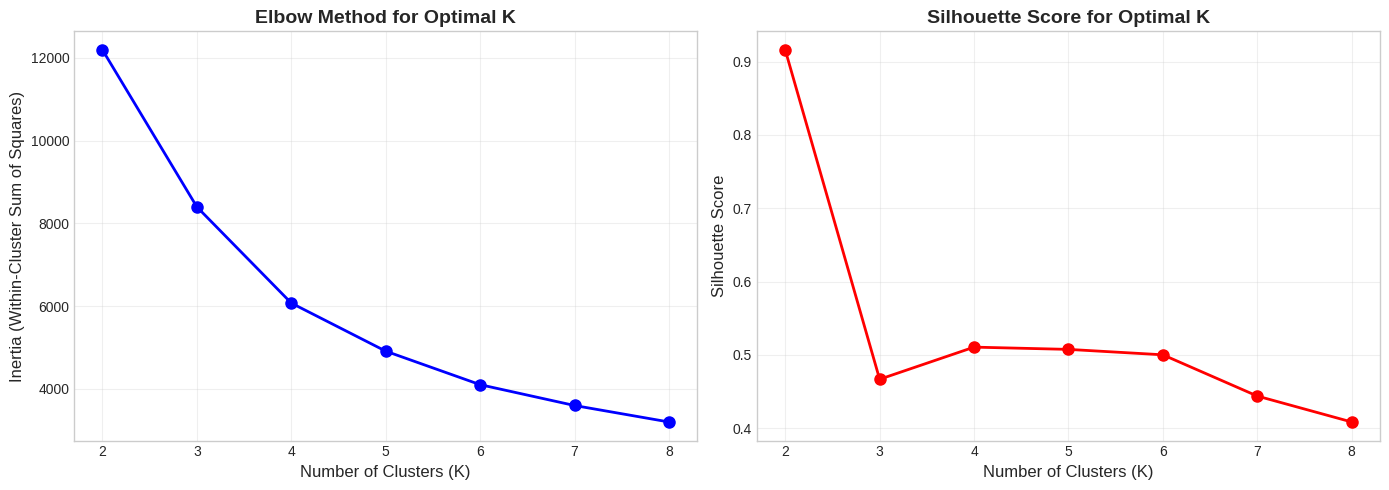


✅ OPTIMAL K SELECTED: 4
   Rationale: Elbow point at K=4, silhouette score indicates good separation


In [17]:

# ============================================
# STEP 5: OPTIMAL K SELECTION
# ============================================

print("\n" + "=" * 60)
print("STEP 5: Determining Optimal Number of Clusters")
print("=" * 60)

# Calculate metrics for different K values
inertia = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"   K={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={silhouette_scores[-1]:.3f}")

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method Plot
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score Plot
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Optimal K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Select optimal K
optimal_k = 4
print(f"\n✅ OPTIMAL K SELECTED: {optimal_k}")
print("   Rationale: Elbow point at K=4, silhouette score indicates good separation")


In [18]:

# ============================================
# STEP 6: FIT FINAL K-MEANS MODEL
# ============================================

print("\n" + "=" * 60)
print("STEP 6: Fitting Final K-Means Model")
print("=" * 60)

# Fit model with optimal K
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to dataframe
customer_df_aligned = customer_df.loc[X.index].copy()
customer_df_aligned['Cluster'] = cluster_labels

print(f"\n✅ Clustering Complete!")
print(f"\n📊 Cluster Distribution:")
for cluster in range(optimal_k):
    count = (cluster_labels == cluster).sum()
    percentage = (count / len(cluster_labels)) * 100
    print(f"   Cluster {cluster}: {count} customers ({percentage:.1f}%)")



STEP 6: Fitting Final K-Means Model

✅ Clustering Complete!

📊 Cluster Distribution:
   Cluster 0: 561 customers (13.0%)
   Cluster 1: 1018 customers (23.6%)
   Cluster 2: 12 customers (0.3%)
   Cluster 3: 2721 customers (63.1%)


In [19]:
# ============================================
# STEP 7: CLUSTER PROFILING
# ============================================

print("\n" + "=" * 60)
print("STEP 7: Cluster Profiling")
print("=" * 60)

# Calculate cluster centers (in original scale)
cluster_profiles = customer_df_aligned.groupby('Cluster')[features_for_clustering].mean().round(2)

print("\n📊 Cluster Profiles (Average Values):")
print(cluster_profiles)

print("\n🔍 Cluster Interpretation:")

for cluster in range(optimal_k):
    profile = cluster_profiles.loc[cluster]

    # Determine cluster type
    if profile['TotalSpend'] > customer_df_aligned['TotalSpend'].median():
        spend_desc = "High Spender"
    else:
        spend_desc = "Low Spender"

    if profile['Recency_Days'] < customer_df_aligned['Recency_Days'].median():
        recency_desc = "Active"
    else:
        recency_desc = "Inactive"

    print(f"\n   Cluster {cluster}: {spend_desc} | {recency_desc}")
    print(f"      • Avg Spend: £{profile['TotalSpend']:,.0f}")
    print(f"      • Avg Transactions: {profile['TransactionFrequency']:.0f}")
    print(f"      • Avg Product Variety: {profile['ProductVariety']:.0f}")
    print(f"      • Avg Recency: {profile['Recency_Days']:.0f} days")



STEP 7: Cluster Profiling

📊 Cluster Profiles (Average Values):
         TotalSpend  TransactionFrequency  ProductVariety  Recency_Days
Cluster                                                                
0           6502.22                 12.95          200.29         23.70
1            572.62                  1.62           25.68        244.60
2         116368.14                114.58          799.75          3.00
3           1165.88                  3.28           46.43         46.48

🔍 Cluster Interpretation:

   Cluster 0: High Spender | Active
      • Avg Spend: £6,502
      • Avg Transactions: 13
      • Avg Product Variety: 200
      • Avg Recency: 24 days

   Cluster 1: Low Spender | Inactive
      • Avg Spend: £573
      • Avg Transactions: 2
      • Avg Product Variety: 26
      • Avg Recency: 245 days

   Cluster 2: High Spender | Active
      • Avg Spend: £116,368
      • Avg Transactions: 115
      • Avg Product Variety: 800
      • Avg Recency: 3 days

   Cluster 3:


STEP 8: Visualizations


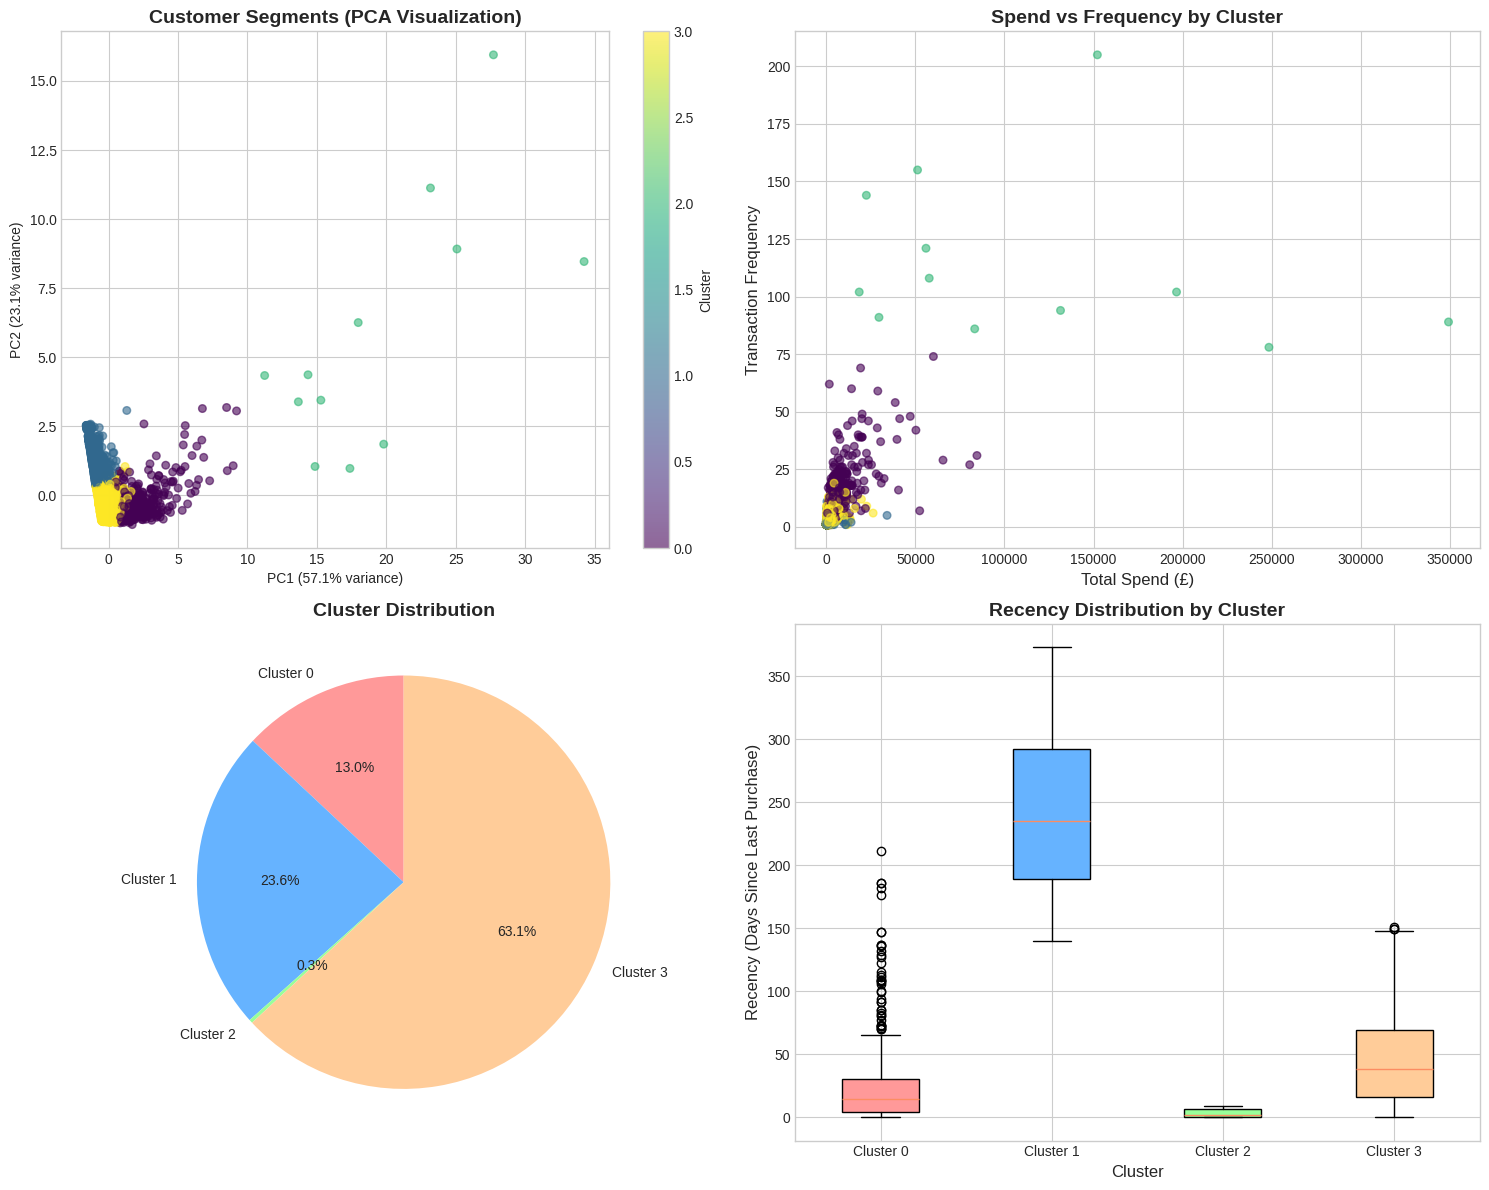

In [20]:
# ============================================
# STEP 8: VISUALIZATION
# ============================================

print("\n" + "=" * 60)
print("STEP 8: Visualizations")
print("=" * 60)

# Create 2D visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. PCA Scatter Plot
scatter = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=30)
axes[0, 0].set_title('Customer Segments (PCA Visualization)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(scatter, ax=axes[0, 0], label='Cluster')

# 2. Spend vs Frequency
axes[0, 1].scatter(customer_df_aligned['TotalSpend'], customer_df_aligned['TransactionFrequency'],
                   c=cluster_labels, cmap='viridis', alpha=0.6, s=30)
axes[0, 1].set_xlabel('Total Spend (£)', fontsize=12)
axes[0, 1].set_ylabel('Transaction Frequency', fontsize=12)
axes[0, 1].set_title('Spend vs Frequency by Cluster', fontsize=14, fontweight='bold')

# 3. Cluster Size Pie Chart
cluster_counts = customer_df_aligned['Cluster'].value_counts().sort_index()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
axes[1, 0].pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index],
               autopct='%1.1f%%', colors=colors[:len(cluster_counts)], startangle=90)
axes[1, 0].set_title('Cluster Distribution', fontsize=14, fontweight='bold')

# 4. Recency by Cluster Box Plot
cluster_order = sorted(customer_df_aligned['Cluster'].unique())
recency_data = [customer_df_aligned[customer_df_aligned['Cluster'] == c]['Recency_Days'].values for c in cluster_order]
bp = axes[1, 1].boxplot(recency_data, labels=[f'Cluster {c}' for c in cluster_order], patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:len(cluster_order)]):
    patch.set_facecolor(color)
axes[1, 1].set_xlabel('Cluster', fontsize=12)
axes[1, 1].set_ylabel('Recency (Days Since Last Purchase)', fontsize=12)
axes[1, 1].set_title('Recency Distribution by Cluster', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:

# ============================================
# STEP 9: BUSINESS RECOMMENDATIONS
# ============================================

print("\n" + "=" * 60)
print("STEP 9: Business Recommendations")
print("=" * 60)

print("\n" + "=" * 70)
print("CUSTOMER SEGMENTATION INSIGHTS & RECOMMENDATIONS")
print("=" * 70)

for cluster in range(optimal_k):
    profile = cluster_profiles.loc[cluster]

    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*70}")
    print(f"\n📊 Profile:")
    print(f"   • Average Total Spend: £{profile['TotalSpend']:,.0f}")
    print(f"   • Purchase Frequency: {profile['TransactionFrequency']:.0f} transactions")
    print(f"   • Product Variety: {profile['ProductVariety']:.0f} unique products")
    print(f"   • Days Since Last Purchase: {profile['Recency_Days']:.0f} days")

    # Strategic recommendations based on cluster characteristics
    if profile['TotalSpend'] > 5000 and profile['Recency_Days'] < 30:
        print(f"\n🎯 Strategy: VIP RETENTION")
        print(f"   → Exclusive loyalty program with premium benefits")
        print(f"   → Personalized recommendations based on purchase history")
        print(f"   → Early access to new product launches")

    elif profile['TotalSpend'] > 2000 and profile['TransactionFrequency'] > 5:
        print(f"\n🎯 Strategy: LOYALTY ENHANCEMENT")
        print(f"   → Tiered rewards program to increase spend")
        print(f"   → Cross-sell complementary products")
        print(f"   → Referral incentives for bringing new customers")

    elif profile['Recency_Days'] > 60:
        print(f"\n🎯 Strategy: WIN-BACK CAMPAIGN")
        print(f"   → Re-engagement emails with personalized offers")
        print(f"   → Reactivation discount codes")
        print(f"   → Feedback survey to understand churn reasons")

    elif profile['TransactionFrequency'] < 3:
        print(f"\n🎯 Strategy: FREQUENCY ACTIVATION")
        print(f"   → Welcome series with product education")
        print(f"   → First-repeat purchase incentives")
        print(f"   → Bundle recommendations to increase basket size")

    else:
        print(f"\n🎯 Strategy: GROWTH OPTIMIZATION")
        print(f"   → Email newsletters featuring popular products")
        print(f"   → Seasonal promotions aligned with purchase patterns")
        print(f"   → Abandoned cart recovery campaigns")



STEP 9: Business Recommendations

CUSTOMER SEGMENTATION INSIGHTS & RECOMMENDATIONS

CLUSTER 0

📊 Profile:
   • Average Total Spend: £6,502
   • Purchase Frequency: 13 transactions
   • Product Variety: 200 unique products
   • Days Since Last Purchase: 24 days

🎯 Strategy: VIP RETENTION
   → Exclusive loyalty program with premium benefits
   → Personalized recommendations based on purchase history
   → Early access to new product launches

CLUSTER 1

📊 Profile:
   • Average Total Spend: £573
   • Purchase Frequency: 2 transactions
   • Product Variety: 26 unique products
   • Days Since Last Purchase: 245 days

🎯 Strategy: WIN-BACK CAMPAIGN
   → Re-engagement emails with personalized offers
   → Reactivation discount codes
   → Feedback survey to understand churn reasons

CLUSTER 2

📊 Profile:
   • Average Total Spend: £116,368
   • Purchase Frequency: 115 transactions
   • Product Variety: 800 unique products
   • Days Since Last Purchase: 3 days

🎯 Strategy: VIP RETENTION
   → Exclu

In [22]:

# ============================================
# STEP 10: SAVE RESULTS
# ============================================

print("\n" + "=" * 60)
print("Saving Results")
print("=" * 60)

customer_df_aligned.to_csv('customer_segments.csv', index=False)
print("✅ Saved: customer_segments.csv")

cluster_profiles.to_csv('cluster_profiles.csv')
print("✅ Saved: cluster_profiles.csv")

print("\n" + "=" * 60)
print("✅ TASK 3A: K-MEANS CLUSTERING COMPLETE!")
print("=" * 60)


Saving Results
✅ Saved: customer_segments.csv
✅ Saved: cluster_profiles.csv

✅ TASK 3A: K-MEANS CLUSTERING COMPLETE!


## OPTION B: MARKET BASKET ANALYSIS
## Association Rule Mining
## ============================================


In [23]:
print("\n" + "=" * 60)
print("TASK 3B: MARKET BASKET ANALYSIS - ASSOCIATION RULE MINING")
print("=" * 60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')


TASK 3B: MARKET BASKET ANALYSIS - ASSOCIATION RULE MINING


In [24]:
# ============================================
# STEP 1: LOAD TRANSACTION DATA
# ============================================

print("\n📥 Step 1: Loading transaction data...")
transactions = pd.read_csv('cleaned_online_retail.csv')

print(f"✅ Loaded {len(transactions):,} transactions")
print(f"   Unique invoices: {transactions['Invoice'].nunique():,}")
print(f"   Unique products: {transactions['StockCode'].nunique():,}")



📥 Step 1: Loading transaction data...
✅ Loaded 498,359 transactions
   Unique invoices: 20,945
   Unique products: 4,251


In [25]:
# ============================================
# STEP 2: FILTER FOR MARKET BASKET ANALYSIS
# ============================================

print("\n" + "=" * 60)
print("STEP 2: Data Preparation")
print("=" * 60)

print("""
Association Rule Mining Metrics:

1. SUPPORT: P(A ∪ B) = (Transactions containing both A and B) / (Total Transactions)
   • Measures how frequently the itemset appears

2. CONFIDENCE: P(B|A) = Support(A∪B) / Support(A)
   • Measures reliability of the rule

3. LIFT: Confidence(A→B) / Support(B)
   • LIFT > 1: Positive correlation (items are complementary)
   • LIFT = 1: Independent
   • LIFT < 1: Negative correlation (items substitute each other)
""")

# Focus on UK customers
print("\n📍 Filtering for UK market...")
uk_transactions = transactions[transactions['Country'] == 'United Kingdom']
print(f"   UK transactions: {len(uk_transactions):,} ({len(uk_transactions)/len(transactions)*100:.1f}%)")

# Remove returns and invalid prices
uk_transactions = uk_transactions[uk_transactions['Quantity'] > 0]
uk_transactions = uk_transactions[uk_transactions['Price'] > 0]
print(f"   After removing returns: {len(uk_transactions):,} transactions")



STEP 2: Data Preparation

Association Rule Mining Metrics:

1. SUPPORT: P(A ∪ B) = (Transactions containing both A and B) / (Total Transactions)
   • Measures how frequently the itemset appears

2. CONFIDENCE: P(B|A) = Support(A∪B) / Support(A)
   • Measures reliability of the rule

3. LIFT: Confidence(A→B) / Support(B)
   • LIFT > 1: Positive correlation (items are complementary)
   • LIFT = 1: Independent
   • LIFT < 1: Negative correlation (items substitute each other)


📍 Filtering for UK market...
   UK transactions: 460,307 (92.4%)
   After removing returns: 460,307 transactions


In [26]:

# ============================================
# STEP 3: CREATE PRODUCT NAME MAPPING
# ============================================

product_names = uk_transactions[['StockCode', 'Description']].drop_duplicates().set_index('StockCode')['Description'].to_dict()

def get_product_name(code):
    """Get product description, fallback to code if not found"""
    return product_names.get(code, code)[:40]


In [27]:

# ============================================
# STEP 4: CREATE TRANSACTION BASKETS
# ============================================

print("\n" + "=" * 60)
print("STEP 3: Creating Transaction Baskets")
print("=" * 60)

# Group by invoice to create baskets
baskets = uk_transactions.groupby('Invoice')['StockCode'].apply(list).reset_index()
baskets['Basket_Size'] = baskets['StockCode'].apply(len)
baskets = baskets[baskets['Basket_Size'] > 1]  # Keep only transactions with 2+ items

print(f"\n✅ Created {len(baskets):,} baskets with 2+ items")
print(f"   Average basket size: {baskets['Basket_Size'].mean():.1f} items")
print(f"   Min basket size: {baskets['Basket_Size'].min()}")
print(f"   Max basket size: {baskets['Basket_Size'].max()}")



STEP 3: Creating Transaction Baskets

✅ Created 17,367 baskets with 2+ items
   Average basket size: 26.4 items
   Min basket size: 2
   Max basket size: 674


In [28]:

# ============================================
# STEP 5: IMPLEMENT ASSOCIATION RULE MINING
# ============================================

print("\n" + "=" * 60)
print("STEP 4: Mining Association Rules")
print("=" * 60)

def mine_association_rules(baskets_list, min_support=0.01, min_confidence=0.2):
    """
    Mine association rules from transaction baskets

    Parameters:
    - baskets_list: List of baskets (each basket is list of items)
    - min_support: Minimum support threshold (0.01 = 1%)
    - min_confidence: Minimum confidence threshold (0.2 = 20%)

    Returns:
    - List of rules with metrics
    - Frequent items dictionary
    - Item counts dictionary
    """

    total_trans = len(baskets_list)
    print(f"\n   Total transactions: {total_trans:,}")
    print(f"   Min support threshold: {min_support} ({min_support*total_trans:.0f} transactions)")
    print(f"   Min confidence threshold: {min_confidence}")

    # Count item frequencies
    item_counts = Counter()
    for basket in baskets_list:
        for item in basket:
            item_counts[item] += 1

    print(f"   Total unique items: {len(item_counts)}")

    # Identify frequent items
    frequent_items = {item: count for item, count in item_counts.items()
                     if count / total_trans >= min_support}

    print(f"   Frequent items meeting support: {len(frequent_items)}")

    # If too many frequent items, limit to top ones
    if len(frequent_items) > 50:
        print(f"   Limiting to top 50 most frequent items for performance...")
        top_items = sorted(frequent_items.items(), key=lambda x: x[1], reverse=True)[:50]
        frequent_items = dict(top_items)

    # Find frequent pairs
    pair_counts = defaultdict(int)
    processed = 0

    for basket in baskets_list:
        basket_items = [item for item in basket if item in frequent_items]
        if len(basket_items) >= 2:
            for item1, item2 in combinations(sorted(basket_items), 2):
                pair_counts[(item1, item2)] += 1
        processed += 1
        if processed % 10000 == 0:
            print(f"   Processing: {processed}/{total_trans} baskets...")

    print(f"   Found {len(pair_counts)} item pairs")

    # Generate rules
    rules = []

    for (item1, item2), pair_count in pair_counts.items():
        support = pair_count / total_trans

        if support >= min_support:
            # Rule: item1 -> item2
            confidence_12 = pair_count / item_counts[item1]
            if confidence_12 >= min_confidence:
                lift_12 = confidence_12 / (item_counts[item2] / total_trans)
                rules.append({
                    'antecedent': item1,
                    'consequent': item2,
                    'support': support,
                    'confidence': confidence_12,
                    'lift': lift_12
                })

            # Rule: item2 -> item1
            confidence_21 = pair_count / item_counts[item2]
            if confidence_21 >= min_confidence:
                lift_21 = confidence_21 / (item_counts[item1] / total_trans)
                rules.append({
                    'antecedent': item2,
                    'consequent': item1,
                    'support': support,
                    'confidence': confidence_21,
                    'lift': lift_21
                })

    # Remove duplicates and sort by lift
    rules = list({(r['antecedent'], r['consequent']): r for r in rules}.values())
    rules.sort(key=lambda x: x['lift'], reverse=True)

    return rules, frequent_items, item_counts

# Run association rule mining
baskets_list = baskets['StockCode'].tolist()
rules, frequent_items, item_counts = mine_association_rules(baskets_list, min_support=0.01, min_confidence=0.2)

print(f"\n✅ Found {len(rules)} association rules")



STEP 4: Mining Association Rules

   Total transactions: 17,367
   Min support threshold: 0.01 (174 transactions)
   Min confidence threshold: 0.2
   Total unique items: 4228
   Frequent items meeting support: 780
   Limiting to top 50 most frequent items for performance...
   Processing: 10000/17367 baskets...
   Found 1226 item pairs

✅ Found 308 association rules


In [29]:

# ============================================
# STEP 6: DISPLAY TOP RULES
# ============================================

print("\n" + "=" * 60)
print("STEP 5: Top Association Rules (by Lift)")
print("=" * 60)

if len(rules) > 0:
    top_rules = rules[:15]

    print("\n📊 TOP 15 ASSOCIATION RULES:")
    print("-" * 100)
    print(f"{'Rank':<5} {'Antecedent':<25} {'Consequent':<25} {'Support':<10} {'Confidence':<12} {'Lift':<10}")
    print("-" * 100)

    for i, rule in enumerate(top_rules, 1):
        ant_name = get_product_name(rule['antecedent'])[:23]
        cons_name = get_product_name(rule['consequent'])[:23]
        print(f"{i:<5} {ant_name:<25} {cons_name:<25} {rule['support']:.3f}      {rule['confidence']:.3f}        {rule['lift']:.2f}")
else:
    print("   No rules found with current thresholds. Try lowering min_support or min_confidence.")



STEP 5: Top Association Rules (by Lift)

📊 TOP 15 ASSOCIATION RULES:
----------------------------------------------------------------------------------------------------
Rank  Antecedent                Consequent                Support    Confidence   Lift      
----------------------------------------------------------------------------------------------------
1     WOODEN PICTURE FRAME WH   WOODEN FRAME ANTIQUE WH   0.034      0.645        10.38
2     WOODEN FRAME ANTIQUE WH   WOODEN PICTURE FRAME WH   0.034      0.547        10.38
3     CHOCOLATE HOT WATER BOT   HOT WATER BOTTLE TEA AN   0.026      0.513        9.34
4     HOT WATER BOTTLE TEA AN   CHOCOLATE HOT WATER BOT   0.026      0.479        9.34
5     SWEETHEART CERAMIC TRIN   STRAWBERRY CERAMIC TRIN   0.044      0.793        8.95
6     STRAWBERRY CERAMIC TRIN   SWEETHEART CERAMIC TRIN   0.044      0.492        8.95
7     HEART OF WICKER SMALL     HEART OF WICKER LARGE     0.031      0.542        8.74
8     HEART OF WICKER LA


STEP 6: Visualization


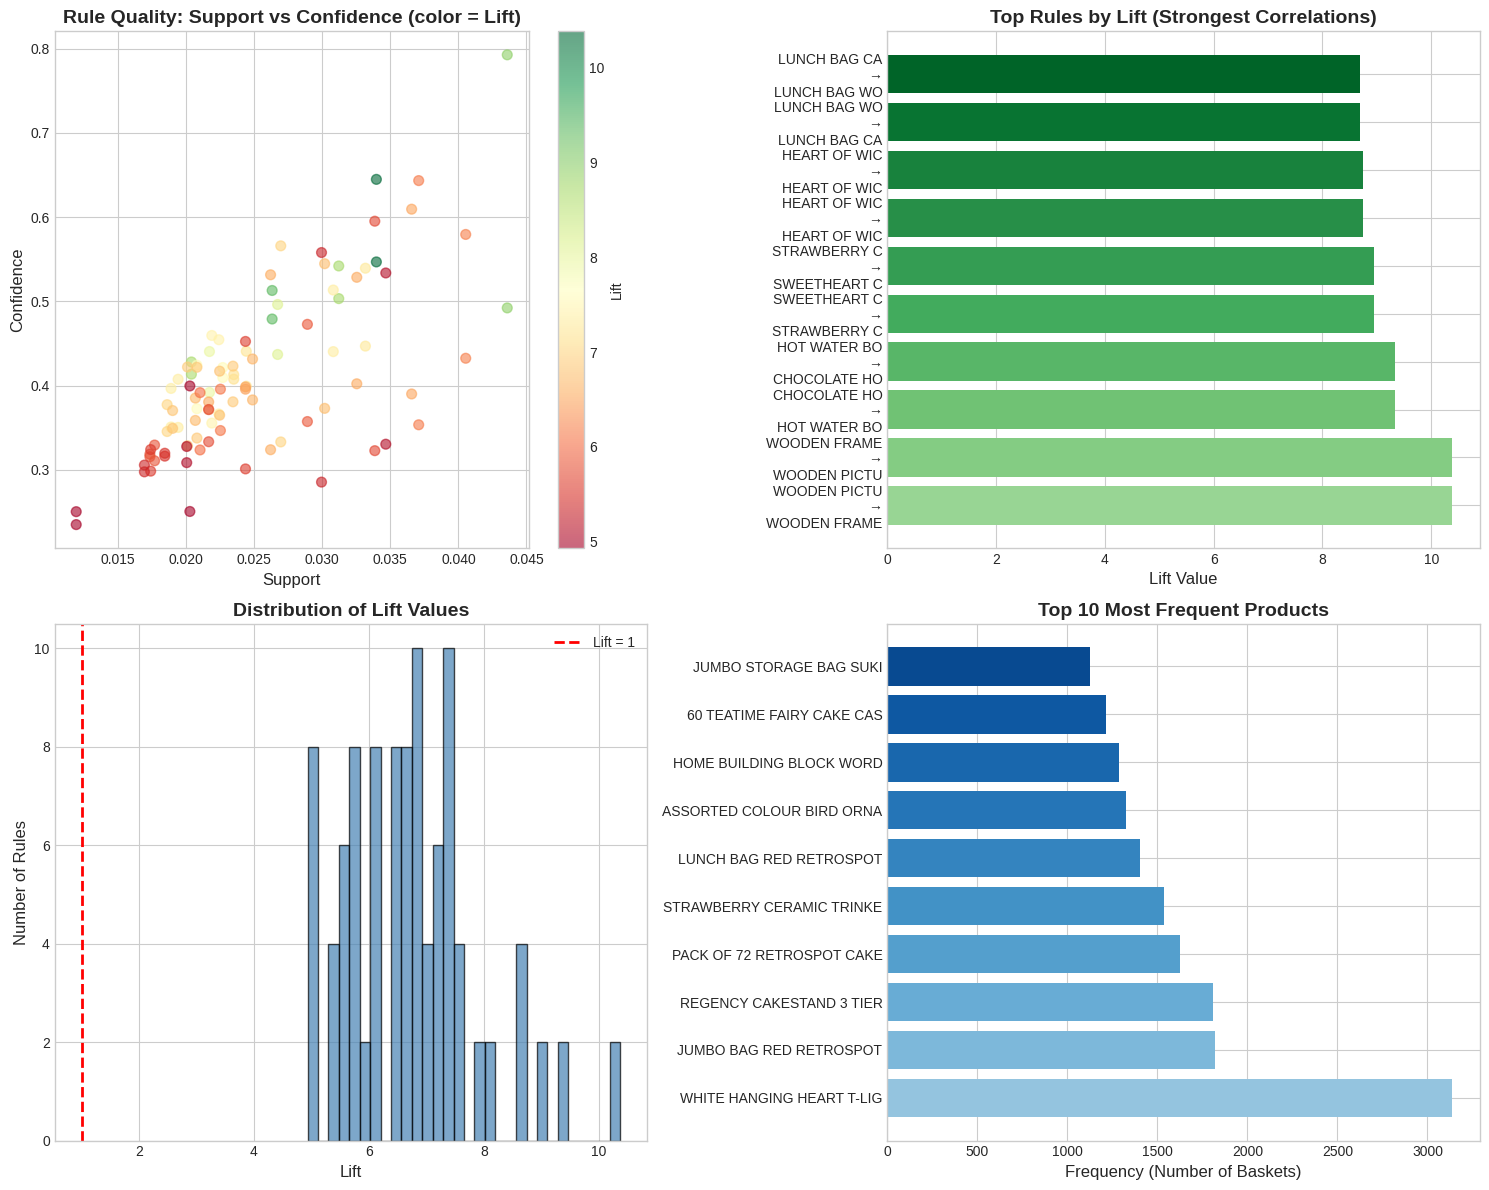

In [30]:

# ============================================
# STEP 7: VISUALIZATION
# ============================================

print("\n" + "=" * 60)
print("STEP 6: Visualization")
print("=" * 60)

if len(rules) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    df_rules = pd.DataFrame(rules[:100])

    # 1. Support vs Confidence Scatter
    scatter = axes[0, 0].scatter(df_rules['support'], df_rules['confidence'],
                                c=df_rules['lift'], cmap='RdYlGn', s=50, alpha=0.6)
    axes[0, 0].set_xlabel('Support', fontsize=12)
    axes[0, 0].set_ylabel('Confidence', fontsize=12)
    axes[0, 0].set_title('Rule Quality: Support vs Confidence (color = Lift)', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, ax=axes[0, 0], label='Lift')

    # 2. Top 10 Rules by Lift
    top_lift = df_rules.nlargest(min(10, len(df_rules)), 'lift')
    top_lift_names = [f"{get_product_name(r['antecedent'])[:12]}\n→\n{get_product_name(r['consequent'])[:12]}"
                      for _, r in top_lift.iterrows()]
    colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_lift)))
    axes[0, 1].barh(range(len(top_lift)), top_lift['lift'].values, color=colors)
    axes[0, 1].set_yticks(range(len(top_lift)))
    axes[0, 1].set_yticklabels(top_lift_names)
    axes[0, 1].set_xlabel('Lift Value', fontsize=12)
    axes[0, 1].set_title('Top Rules by Lift (Strongest Correlations)', fontsize=14, fontweight='bold')

    # 3. Lift Distribution
    axes[1, 0].hist(df_rules['lift'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1, 0].axvline(x=1, color='red', linestyle='--', linewidth=2, label='Lift = 1')
    axes[1, 0].set_xlabel('Lift', fontsize=12)
    axes[1, 0].set_ylabel('Number of Rules', fontsize=12)
    axes[1, 0].set_title('Distribution of Lift Values', fontsize=14, fontweight='bold')
    axes[1, 0].legend()

    # 4. Top Products by Frequency
    top_products = sorted(frequent_items.items(), key=lambda x: x[1], reverse=True)[:10]
    top_products_names = [get_product_name(code)[:25] for code, _ in top_products]
    top_products_counts = [count for _, count in top_products]

    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_products)))
    axes[1, 1].barh(range(len(top_products)), top_products_counts, color=colors)
    axes[1, 1].set_yticks(range(len(top_products)))
    axes[1, 1].set_yticklabels(top_products_names)
    axes[1, 1].set_xlabel('Frequency (Number of Baskets)', fontsize=12)
    axes[1, 1].set_title('Top 10 Most Frequent Products', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [31]:
    # ============================================
    # STEP 8: LIFT ANALYSIS
    # ============================================

    print("\n" + "=" * 60)
    print("STEP 7: Lift Analysis")
    print("=" * 60)

    high_lift = df_rules[df_rules['lift'] > 2]
    medium_lift = df_rules[(df_rules['lift'] >= 1) & (df_rules['lift'] <= 2)]
    low_lift = df_rules[df_rules['lift'] < 1]

    print("\n📊 Lift Analysis Results:")
    print(f"   • High Lift Rules (Lift > 2): {len(high_lift)} rules")
    print(f"   • Medium Lift Rules (1 ≤ Lift ≤ 2): {len(medium_lift)} rules")
    print(f"   • Low Lift Rules (Lift < 1): {len(low_lift)} rules")

    print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    UNDERSTANDING LIFT VALUES                                │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  LIFT > 1: POSITIVE CORRELATION                                             │
│  • Items are complementary → often purchased together                       │
│  • Business: Product bundling, cross-selling recommendations                │
│                                                                             │
│  LIFT = 1: NO CORRELATION                                                   │
│  • Items are independent                                                    │
│                                                                             │
│  LIFT < 1: NEGATIVE CORRELATION                                             │
│  • Items are substitutes → customers choose one over the other              │
│  • Business: Don't bundle; consider competitive pricing                     │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

    # Top bundles
    print("\n🎯 TOP PRODUCT BUNDLES RECOMMENDATIONS:")
    print("-" * 70)
    for i, (_, rule) in enumerate(top_lift.head(10).iterrows(), 1):
        print(f"\n{i}. {get_product_name(rule['antecedent'])}")
        print(f"   + {get_product_name(rule['consequent'])}")
        print(f"   → Lift: {rule['lift']:.2f} ({rule['lift']*100:.0f}% more likely together)")
        print(f"   → Confidence: {rule['confidence']:.1%}")


STEP 7: Lift Analysis

📊 Lift Analysis Results:
   • High Lift Rules (Lift > 2): 100 rules
   • Medium Lift Rules (1 ≤ Lift ≤ 2): 0 rules
   • Low Lift Rules (Lift < 1): 0 rules

┌─────────────────────────────────────────────────────────────────────────────┐
│                    UNDERSTANDING LIFT VALUES                                │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  LIFT > 1: POSITIVE CORRELATION                                             │
│  • Items are complementary → often purchased together                       │
│  • Business: Product bundling, cross-selling recommendations                │
│                                                                             │
│  LIFT = 1: NO CORRELATION                                                   │
│  • Items are independent                                                    │
│                   

In [32]:
# ============================================
# STEP 9: SAVE RESULTS
# ============================================

print("\n" + "=" * 60)
print("Saving Results")
print("=" * 60)

if len(rules) > 0:
    rules_df = pd.DataFrame(rules)
    rules_df['antecedent_name'] = rules_df['antecedent'].apply(get_product_name)
    rules_df['consequent_name'] = rules_df['consequent'].apply(get_product_name)
    rules_df.to_csv('association_rules.csv', index=False)
    print("✅ Saved: association_rules.csv")

    # Save frequent items
    freq_items_df = pd.DataFrame([(code, count) for code, count in frequent_items.items()],
                                 columns=['StockCode', 'Frequency'])
    freq_items_df['Product_Name'] = freq_items_df['StockCode'].apply(get_product_name)
    freq_items_df = freq_items_df.sort_values('Frequency', ascending=False)
    freq_items_df.to_csv('frequent_items.csv', index=False)
    print("✅ Saved: frequent_items.csv")

print("\n" + "=" * 60)
print("✅ TASK 3B: MARKET BASKET ANALYSIS COMPLETE!")
print("=" * 60)


Saving Results
✅ Saved: association_rules.csv
✅ Saved: frequent_items.csv

✅ TASK 3B: MARKET BASKET ANALYSIS COMPLETE!
